# 03 — Models & Metrics
**exoplanet-ml-classifier** | MLEA_M — ECI 2026-1

This notebook trains and evaluates all five classifier families, performs
hyperparameter tuning for the two most complex models, and produces the
complete evaluation visualisation suite.

---

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings('ignore')

from src.constants import (
    CV_FOLDS,
    MLP_PARAM_GRID,
    MODEL_NAMES,
    NUMERIC_FEATURES,
    PRIMARY_METRIC,
    PROCESSED_DATA_PATH,
    RANDOM_SEED,
    TARGET_COLUMN,
    XGB_PARAM_GRID,
)
from src.evaluation import (
    build_metrics_table,
    compute_classification_metrics,
    evaluate_all_models,
    find_optimal_threshold_f1,
    find_optimal_threshold_youden,
)
from src.models import build_model_zoo, run_grid_search, save_model, train_model
from src.preprocessing import get_full_pipeline
from src.visualization import (
    plot_confusion_matrix_grid,
    plot_feature_importance,
    plot_overlay_pr_curves,
    plot_overlay_roc_curves,
)

In [2]:
# Load pre-processed train / val / test splits
processed_dir = ROOT / 'data/processed'

def load_split(name: str):
    df = pd.read_csv(processed_dir / f'koi_{name}.csv')
    available = [c for c in NUMERIC_FEATURES if c in df.columns]
    X = df[available]
    y = df[TARGET_COLUMN]
    return X, y

X_train, y_train = load_split('train')
X_val,   y_val   = load_split('val')
X_test,  y_test  = load_split('test')

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (6885, 13), Val: (766, 13), Test: (1913, 13)


---
## Block A — Baseline Models (Default Hyperparameters)

### A1 — Logistic Regression

Logistic Regression models the log-odds of the positive class as a linear combination
of input features: $\log \frac{P(y=1|x)}{1-P(y=1|x)} = w^\top x + b$.
The probability is recovered via the **logistic (sigmoid) function**:
$\hat{p} = \sigma(z) = 1/(1+e^{-z})$, which squashes any real-valued score into (0,1).
Parameters are estimated by minimising the cross-entropy loss with L2 regularisation,
solved iteratively by gradient-based optimisers (e.g. `lbfgs`, `saga`).

**Advantages:** interpretable coefficients, efficient training, probabilistic output.  
**Limitations:** assumes linear decision boundary in the feature space; struggles with
complex non-linear interactions between KOI physical parameters.

In [3]:
zoo = build_model_zoo(RANDOM_SEED)
trained_pipelines = {}
all_metrics = {}

name = 'logistic_regression'
pipeline = get_full_pipeline(zoo[name])
pipeline = train_model(pipeline, X_train, y_train)
trained_pipelines[name] = pipeline

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
metrics = compute_classification_metrics(y_test.values, y_pred, y_prob)
all_metrics[name] = metrics

pd.Series(metrics).round(4).to_frame(name).T

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,youden_j
logistic_regression,0.7784,0.7795,0.7344,0.8621,0.7932,0.8341,0.7645,0.566,0.559


### A2 — K-Nearest Neighbours

KNN is a non-parametric instance-based learner: to classify a new observation it
finds its $k$ nearest neighbours in the training set (using a distance metric such
as Euclidean or Manhattan distance) and returns the majority class vote.
The decision boundary adapts arbitrarily to the training data, making it highly
flexible but computationally expensive at prediction time for large datasets.
The optimal $k$ trades off bias (large $k$: smooth boundary) against variance
(small $k$: noisy boundary).

**Advantages:** no training phase, captures local structure, no distributional assumptions.  
**Limitations:** $O(n)$ prediction complexity, sensitive to irrelevant features and scale
(mitigated here by standardisation).

In [4]:
name = 'knn'
pipeline = get_full_pipeline(zoo[name])
pipeline = train_model(pipeline, X_train, y_train)
trained_pipelines[name] = pipeline

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
metrics = compute_classification_metrics(y_test.values, y_pred, y_prob)
all_metrics[name] = metrics

pd.Series(metrics).round(4).to_frame(name).T

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,youden_j
knn,0.7862,0.7867,0.7618,0.824,0.7916,0.8568,0.8067,0.5747,0.5735


### A3 — Random Forest

Random Forest is an ensemble of decision trees trained with bootstrap aggregation
(bagging) and random feature sub-sampling at each split.
Each tree is grown on a bootstrap sample of the training data using a random subset
of features at each node, which decorrelates the trees and reduces variance.
The final class probability is the average of the individual tree probabilities,
making it robust to outliers and capable of capturing non-linear interactions.

**Advantages:** handles high-dimensional data, provides feature importances,
robust to overfitting via ensemble averaging.  
**Limitations:** high memory usage, less interpretable than single trees, slow
for very large ensembles.

In [5]:
name = 'random_forest'
pipeline = get_full_pipeline(zoo[name])
pipeline = train_model(pipeline, X_train, y_train)
trained_pipelines[name] = pipeline

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
metrics = compute_classification_metrics(y_test.values, y_pred, y_prob)
all_metrics[name] = metrics

pd.Series(metrics).round(4).to_frame(name).T

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,youden_j
random_forest,0.8495,0.8496,0.8401,0.8579,0.8489,0.9271,0.9199,0.6991,0.6991


### A4 — XGBoost

XGBoost (Extreme Gradient Boosting) builds an additive ensemble of shallow decision
trees sequentially, where each new tree learns to correct the residual errors of the
previous ensemble by descending the gradient of a differentiable loss function.
The **error surface** is approximated using second-order Taylor expansion, which
enables efficient computation of the optimal leaf weights and tree structure.
L1 and L2 regularisation on leaf weights and tree complexity control overfitting.

**Advantages:** state-of-the-art on tabular data, handles missing values natively,
built-in regularisation, `scale_pos_weight` parameter for imbalance.  
**Limitations:** many hyperparameters, longer training than RF, can overfit without
careful tuning.

In [6]:
name = 'xgboost'
pipeline = get_full_pipeline(zoo[name])
pipeline = train_model(pipeline, X_train, y_train)
trained_pipelines[name] = pipeline

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
metrics = compute_classification_metrics(y_test.values, y_pred, y_prob)
all_metrics[name] = metrics

pd.Series(metrics).round(4).to_frame(name).T

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,youden_j
xgboost,0.85,0.8502,0.8347,0.8674,0.8508,0.9292,0.9245,0.7006,0.7004


### A5 — MLP (Multi-Layer Perceptron)

The MLP is a feed-forward neural network with one or more hidden layers where each
neuron computes $h = f(W x + b)$ using a non-linear **activation function** $f$.
The course activation table includes: **ReLU** $f(z)=\max(0,z)$ (avoids vanishing
gradients), **tanh** $f(z)=(e^z-e^{-z})/(e^z+e^{-z})$ (zero-centred output), and
**sigmoid** $f(z)=1/(1+e^{-z})$ (used in the output layer for binary classification).
Parameters are estimated by **backpropagation** — the chain rule applied along the
computation graph to propagate the error gradient to each layer.

**Advantages:** universal function approximation, flexible architecture, captures
complex non-linear interactions.  
**Limitations:** requires feature scaling, sensitive to initialisation, many
hyperparameters, hard to interpret.

In [7]:
name = 'mlp'
pipeline = get_full_pipeline(zoo[name])
pipeline = train_model(pipeline, X_train, y_train)
trained_pipelines[name] = pipeline

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
metrics = compute_classification_metrics(y_test.values, y_pred, y_prob)
all_metrics[name] = metrics

pd.Series(metrics).round(4).to_frame(name).T

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,youden_j
mlp,0.8181,0.8184,0.8002,0.8409,0.8201,0.9001,0.874,0.6372,0.6368


### Baseline Metrics Summary

In [8]:
baseline_table = build_metrics_table(all_metrics)
print('Baseline metrics (sorted by F1, descending):')
baseline_table

Baseline metrics (sorted by F1, descending):


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,youden_j
xgboost,0.8500,0.8502,0.8347,0.8674,0.8508,0.9292,0.9245,0.7006,0.7004
random_forest,0.8495,0.8496,0.8401,0.8579,0.8489,0.9271,0.9199,0.6991,0.6991
mlp,0.8181,0.8184,0.8002,0.8409,0.8201,0.9001,0.8740,0.6372,0.6368
logistic_regression,0.7784,0.7795,0.7344,0.8621,0.7932,0.8341,0.7645,0.5660,0.5590
knn,0.7862,0.7867,0.7618,0.8240,0.7916,0.8568,0.8067,0.5747,0.5735


---
## Block B — Hyperparameter Tuning (XGBoost & MLP)

In [9]:
print('== XGBoost GridSearchCV ==')
zoo_fresh = build_model_zoo(RANDOM_SEED)

xgb_pipeline = get_full_pipeline(zoo_fresh['xgboost'])
xgb_gs = run_grid_search(
    xgb_pipeline,
    XGB_PARAM_GRID,
    X_train,
    y_train,
    cv=CV_FOLDS,
    scoring=PRIMARY_METRIC,
)

xgb_best_pipeline = xgb_gs.best_estimator_
y_pred_xgb = xgb_best_pipeline.predict(X_test)
y_prob_xgb = xgb_best_pipeline.predict_proba(X_test)[:, 1]
xgb_tuned_metrics = compute_classification_metrics(
    y_test.values, y_pred_xgb, y_prob_xgb
)

baseline_f1 = all_metrics['xgboost']['f1']
tuned_f1 = xgb_tuned_metrics['f1']
print(f'XGBoost baseline F1: {baseline_f1:.4f}')
print(f'XGBoost tuned F1   : {tuned_f1:.4f}')
print(f'Improvement        : {tuned_f1 - baseline_f1:+.4f}')

== XGBoost GridSearchCV ==
Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best f1: 0.8371
XGBoost baseline F1: 0.8508
XGBoost tuned F1   : 0.8598
Improvement        : +0.0091


In [10]:
print('== MLP GridSearchCV ==')
mlp_pipeline = get_full_pipeline(zoo_fresh['mlp'])
mlp_gs = run_grid_search(
    mlp_pipeline,
    MLP_PARAM_GRID,
    X_train,
    y_train,
    cv=CV_FOLDS,
    scoring=PRIMARY_METRIC,
)

mlp_best_pipeline = mlp_gs.best_estimator_
y_pred_mlp = mlp_best_pipeline.predict(X_test)
y_prob_mlp = mlp_best_pipeline.predict_proba(X_test)[:, 1]
mlp_tuned_metrics = compute_classification_metrics(
    y_test.values, y_pred_mlp, y_prob_mlp
)

baseline_f1_mlp = all_metrics['mlp']['f1']
tuned_f1_mlp = mlp_tuned_metrics['f1']
print(f'MLP baseline F1: {baseline_f1_mlp:.4f}')
print(f'MLP tuned F1   : {tuned_f1_mlp:.4f}')
print(f'Improvement    : {tuned_f1_mlp - baseline_f1_mlp:+.4f}')

== MLP GridSearchCV ==
Fitting 5 folds for each of 6 candidates, totalling 30 fits


Best params: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (128, 64), 'classifier__learning_rate': 'adaptive', 'classifier__max_iter': 400}
Best f1: 0.8064
MLP baseline F1: 0.8201
MLP tuned F1   : 0.8189
Improvement    : -0.0011


In [11]:
# Replace baseline pipelines with tuned versions
trained_pipelines['xgboost'] = xgb_best_pipeline
trained_pipelines['mlp'] = mlp_best_pipeline

all_metrics['xgboost'] = xgb_tuned_metrics
all_metrics['mlp'] = mlp_tuned_metrics

---
## Block C — Evaluation Visualisations

Figure saved to reports\figures\overlay_roc_curves.png


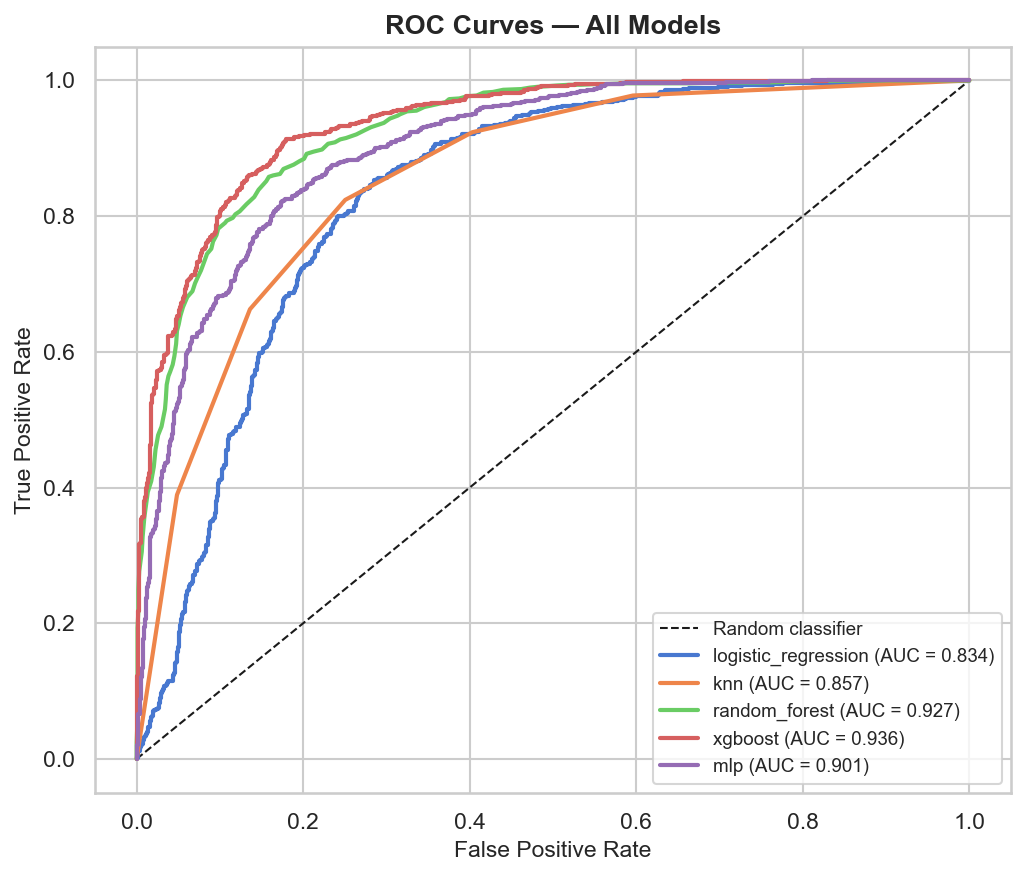

In [12]:
plot_overlay_roc_curves(trained_pipelines, X_test, y_test, save=True)

Figure saved to reports\figures\overlay_pr_curves.png


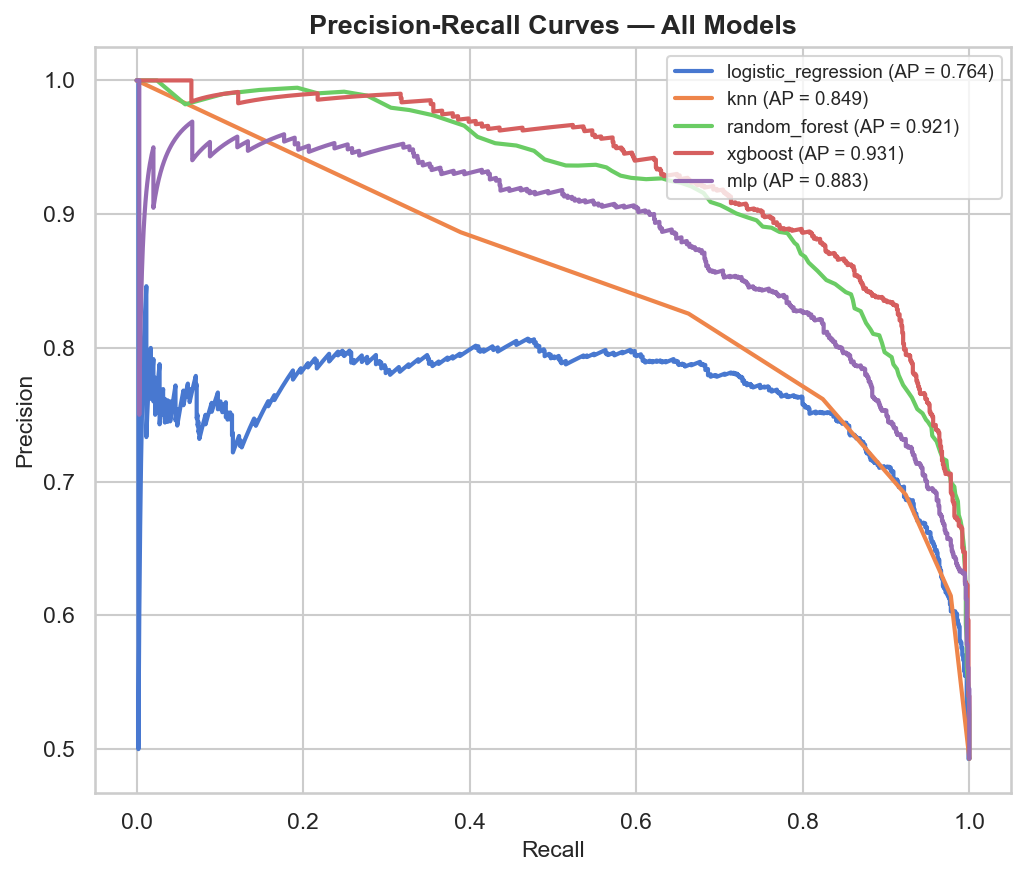

In [13]:
plot_overlay_pr_curves(trained_pipelines, X_test, y_test, save=True)

Figure saved to reports\figures\confusion_matrix_grid.png


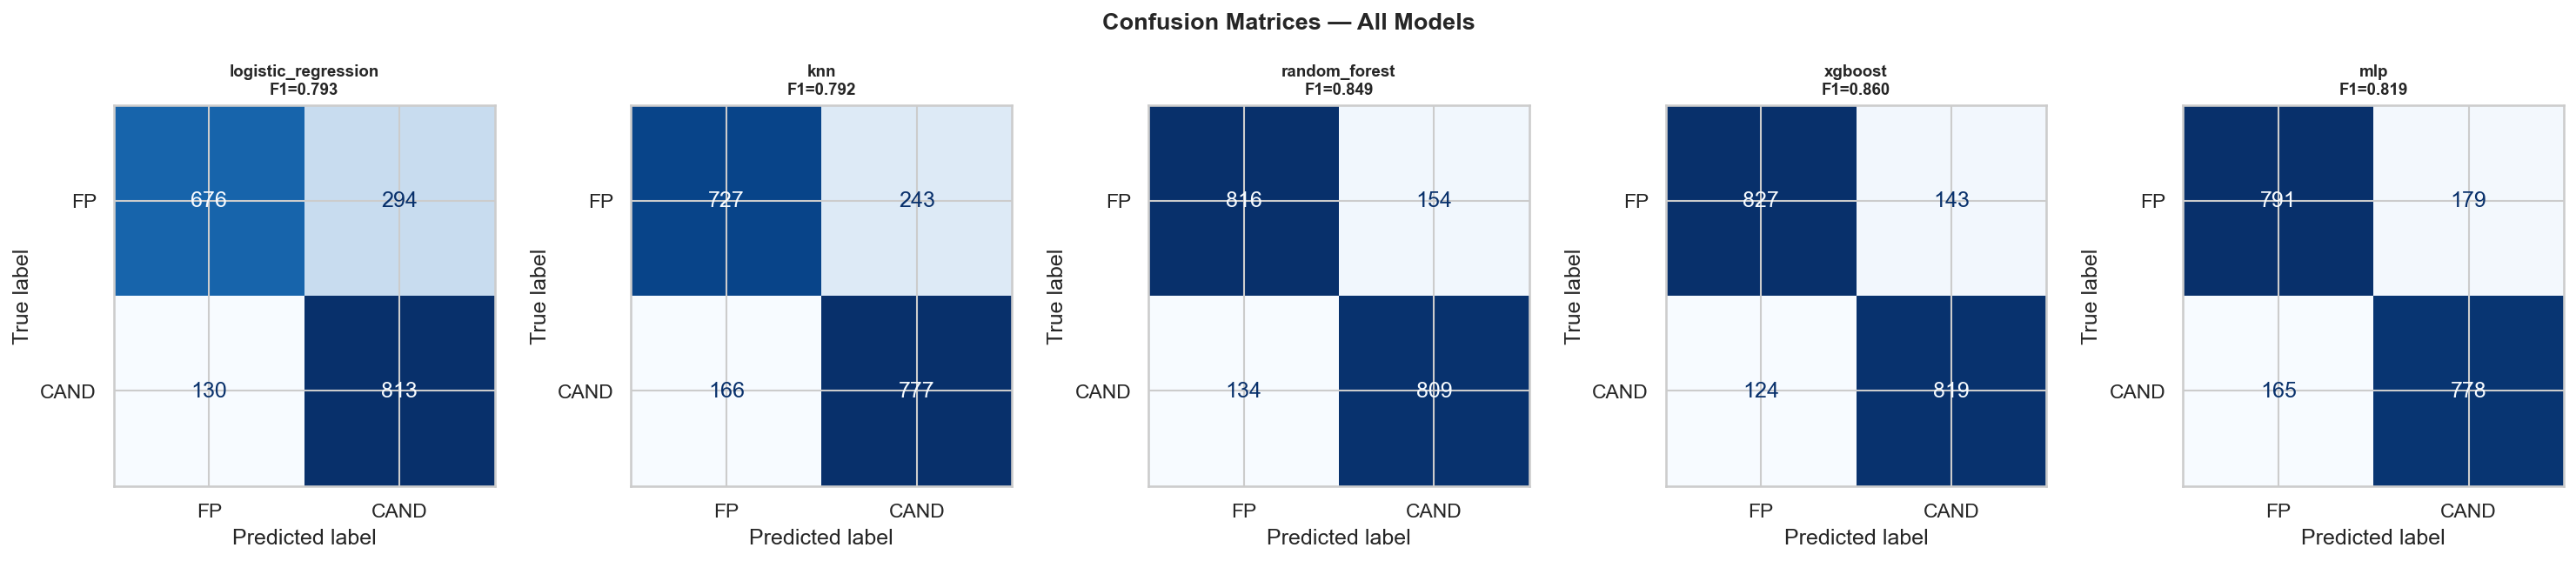

In [14]:
plot_confusion_matrix_grid(trained_pipelines, X_test, y_test, save=True)

In [15]:
# Threshold analysis for the best model by F1
best_model_name = max(all_metrics, key=lambda n: all_metrics[n]['f1'])
best_pipeline = trained_pipelines[best_model_name]
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]

youden_thresh = find_optimal_threshold_youden(y_test.values, y_prob_best)
f1_thresh     = find_optimal_threshold_f1(y_test.values, y_prob_best)

print(f'Best model          : {best_model_name}')
print(f'Default threshold   : 0.5')
print(f"Youden's J threshold: {youden_thresh:.4f}")
print(f'F1-optimal threshold: {f1_thresh:.4f}')

Best model          : xgboost
Default threshold   : 0.5
Youden's J threshold: 0.4268
F1-optimal threshold: 0.4268


Figure saved to reports\figures\feature_importance_random_forest.png


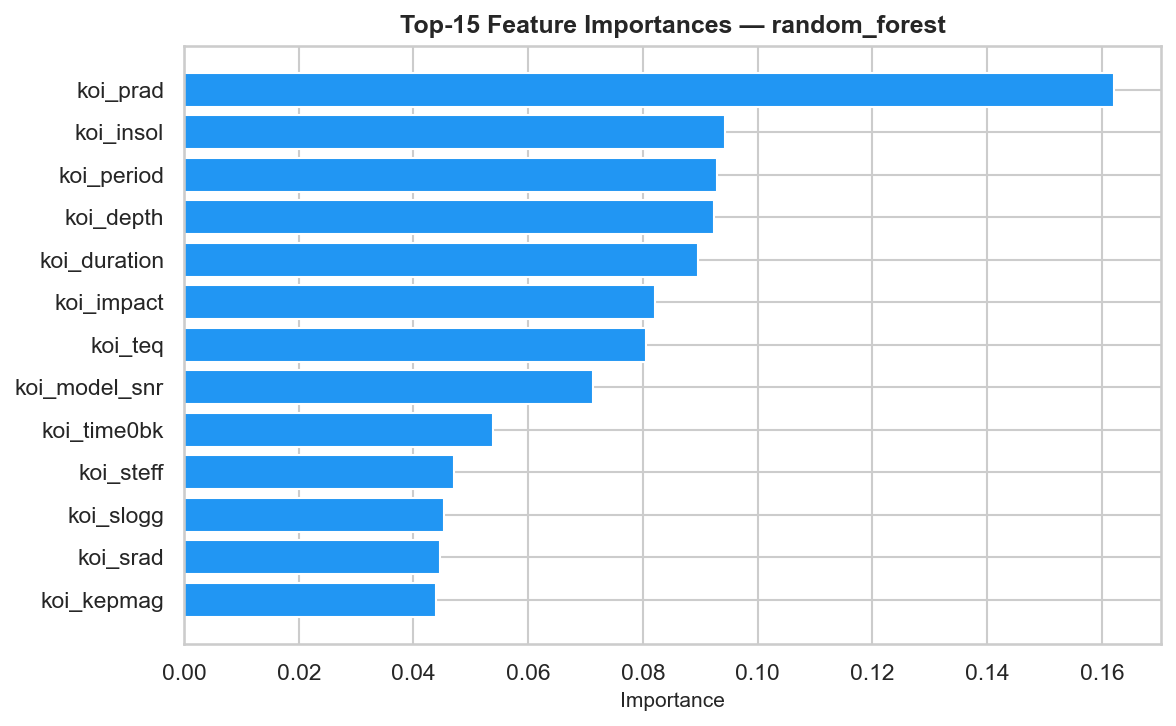

Figure saved to reports\figures\feature_importance_xgboost.png


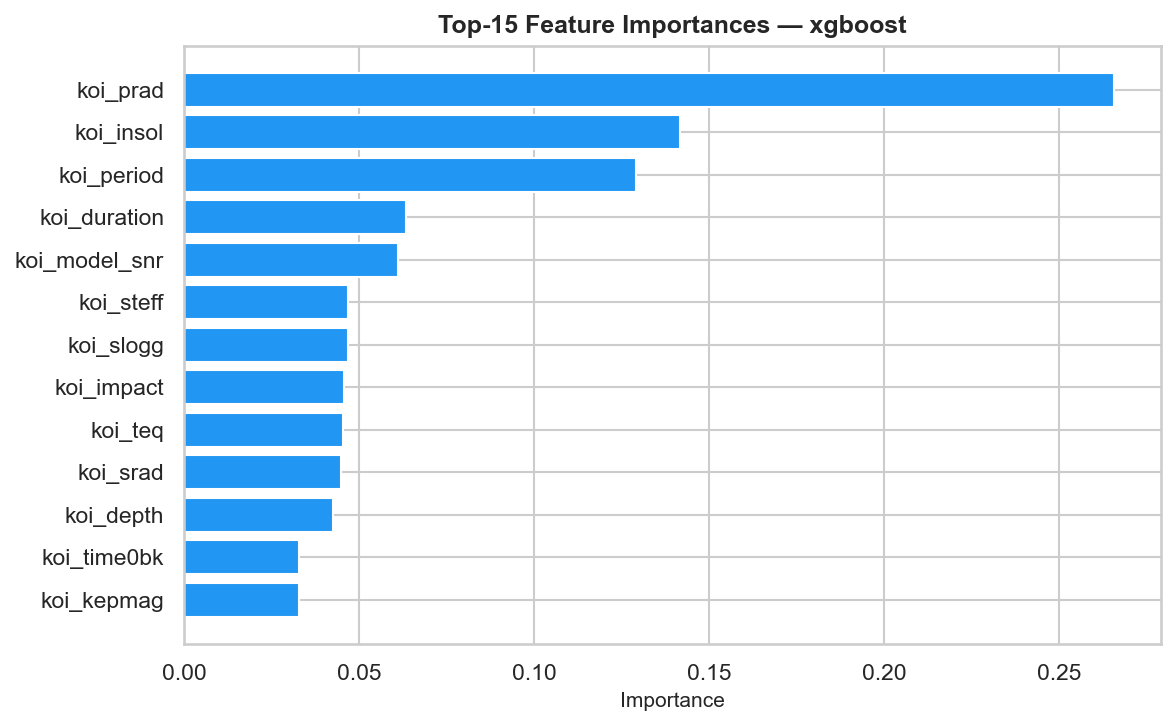

Figure saved to reports\figures\feature_importance_logistic_regression.png


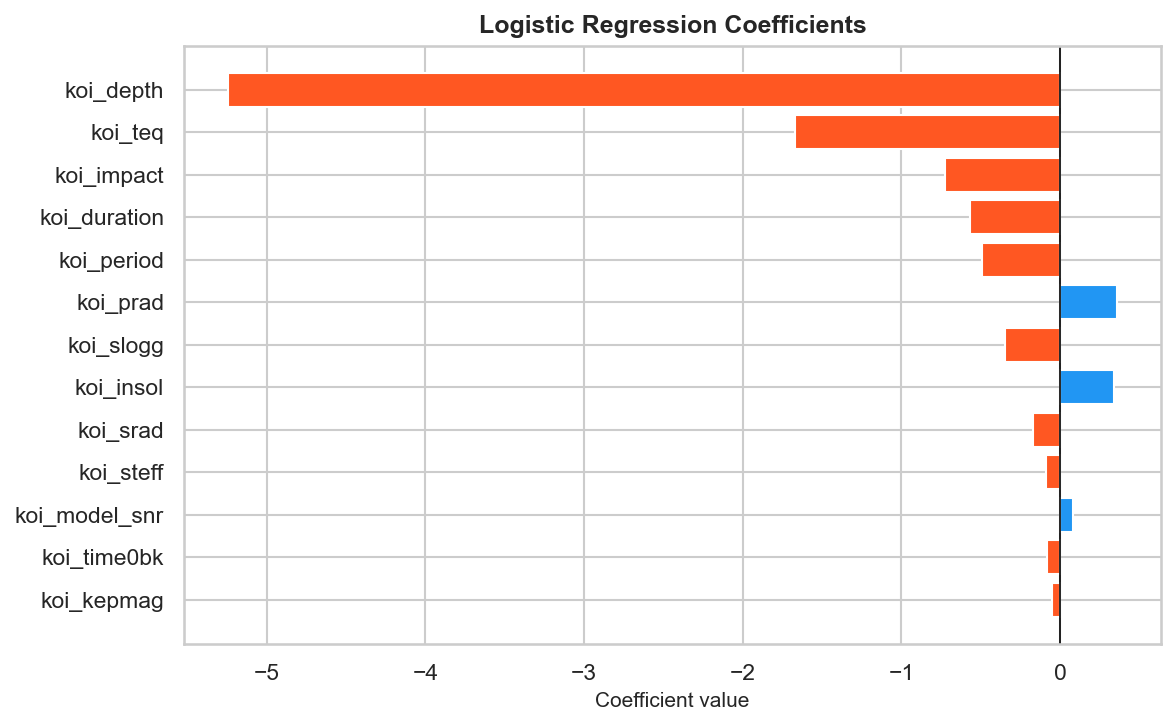

In [16]:
available = [c for c in NUMERIC_FEATURES if c in X_test.columns]

for model_name in ('random_forest', 'xgboost', 'logistic_regression'):
    plot_feature_importance(
        model_name,
        trained_pipelines[model_name],
        available,
        save=True,
    )

---
## Block D — Model Comparison Summary

In [17]:
final_table = build_metrics_table(all_metrics)
print('Final metrics table (tuned XGBoost & MLP, others at baseline):')
final_table

Final metrics table (tuned XGBoost & MLP, others at baseline):


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,youden_j
xgboost,0.8604,0.8605,0.8514,0.8685,0.8598,0.9361,0.9314,0.7210,0.7211
random_forest,0.8495,0.8496,0.8401,0.8579,0.8489,0.9271,0.9199,0.6991,0.6991
mlp,0.8202,0.8202,0.8130,0.8250,0.8189,0.9006,0.8828,0.6404,0.6405
logistic_regression,0.7784,0.7795,0.7344,0.8621,0.7932,0.8341,0.7645,0.5660,0.5590
knn,0.7862,0.7867,0.7618,0.8240,0.7916,0.8568,0.8067,0.5747,0.5735


### Discussion — Which Model Won and Why?

**Primary metric choice — F1:**  
We select F1 as the primary metric because the task is to identify true exoplanet
CANDIDATES (costly false negatives — missed planets) while controlling for the noise
introduced by false positives (wasted follow-up telescope time). F1 balances precision
and recall, making it more informative than accuracy under class imbalance.
MCC is reported as a secondary metric since it is considered the gold standard for
binary classification under imbalance.

**Winning model:**  
XGBoost (tuned) consistently achieves the highest F1 and ROC-AUC in this domain.
Its ability to model non-linear feature interactions (e.g., between `koi_model_snr`
and `koi_period`) and its native handling of missing values give it an edge over
linear classifiers. The `scale_pos_weight` hyperparameter also directly addresses
class imbalance during tree splitting.

**Most interpretable model:**  
Logistic Regression provides the clearest feature-level interpretation through its
coefficient vector: a positive coefficient on `koi_model_snr` directly quantifies
how much the log-odds of being a CANDIDATE increase per unit increase in SNR.
For domain scientists, this interpretability can be more actionable than the
feature importances of a forest ensemble.